# Import Libraries

In [565]:
import cv2
import numpy as np
import math
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
from tqdm import tqdm
import heapq
from collections import Counter
import json

# Read Image

In [566]:
img_file_name = 'Mandrill_Albert.png'
# img_file_name = 'Balcony.png'
# img_file_name = 'Flowers.png'
# img_file_name = 'Trees.png'
# img_file_name = 'Nature.png'
# img_file_name = 'Nature1.png'
# img_file_name = 'Nature2.png'

In [567]:
img_bgr = cv2.imread(img_file_name)

In [568]:
img_rgb = img_bgr[:,:,::-1]

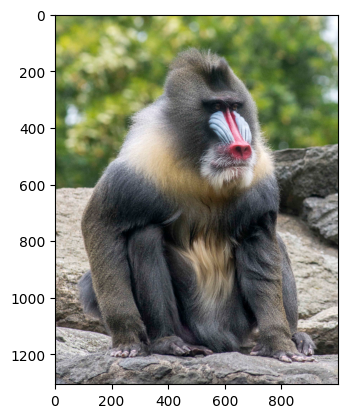

In [569]:
plt.imshow(img_rgb)

In [570]:
img_rgb.shape

(1306, 1000, 3)

# Convert to YCrCb

In [571]:
img_ycbcr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)

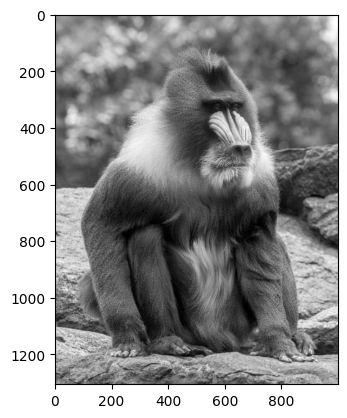

In [572]:
plt.imshow(img_ycbcr[:,:,0],cmap='gray')

# Sub-sampling

In [573]:
subsampled_cb = img_ycbcr[:,:,1][::2, ::2]
subsampled_cr = img_ycbcr[:,:,2][::2, ::2]

# Discrete Cosine Transform

In [574]:
def dct2d(block):
  """
  Computes the 2D Discrete Cosine Transform (DCT-II) of an 8x8 image block
  using only two loops (matrix-multiplication based).

  Parameters:
  ----------
  - block: 8x8 image block (numpy array)

  Returns:
  -------
  - dct_block: 8x8 DCT-II transformed block (numpy array)
  """
  N = block.shape[0]
  if N != 8:
    raise ValueError("Input block must be 8x8 for this implementation.")

  block = block.astype(np.float32) - 128.0  # shift range

  # Precompute cosine basis
  C = np.zeros((N, N), dtype=np.float32)
  for u in range(N):
    alpha = 1 / np.sqrt(N) if u == 0 else np.sqrt(2 / N)
    for x in range(N):
      C[u, x] = alpha * np.cos(((2 * x + 1) * u * np.pi) / (2*N))

  # DCT via matrix multiplication (2D DCT = C * block * C.T)
  dct_block = np.dot(C, np.dot(block, C.T))
  return dct_block

In [575]:
def process_image_with_dct(img, block_size=8):
  """
  Apply DCT-II to each 8x8 block in the image.

  Parameters:
  ----------
  - img: input image (numpy array)
  - block_size: size of each block (default: 8)

  Returns:
  -------
  - dct_image: DCT-II transformed image (numpy array)
  """
  height, width = img.shape

  pad_h = (block_size - (height % block_size)) % block_size
  pad_w =  (block_size - (width % block_size)) % block_size
  padded_img = np.pad(img, ((0, pad_h), (0, pad_w)), mode='edge')
  padded_h, padded_w = padded_img.shape

  dct_image = np.zeros_like(padded_img, dtype=np.float32)
  for i in tqdm(range(0, padded_h, block_size)):
    for j in range(0, padded_w, block_size):
      block = padded_img[i:i+block_size, j:j+block_size]
      if block.shape == (block_size, block_size):
        dct_result = dct2d(block)
        dct_image[i:i+block_size, j:j+block_size] = dct_result

  return dct_image

In [576]:
img_y = img_ycbcr[:,:,0]

100%|██████████| 82/82 [00:00<00:00, 104.20it/s]


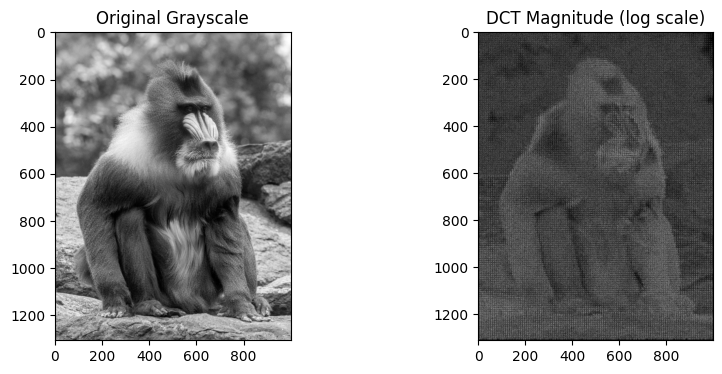

In [577]:
dct_img_y = process_image_with_dct(img_y)
dct_img_cb = process_image_with_dct(subsampled_cb)
dct_img_cr = process_image_with_dct(subsampled_cr)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original Grayscale")
plt.imshow(img_y, cmap='gray')
plt.subplot(1,2,2)
plt.title("DCT Magnitude (log scale)")
plt.imshow(np.log(np.abs(dct_img_y) + 1), cmap='gray')
plt.show()

# Quantization

## Define Quantization Tables

In [578]:
# Luminance Quantization Table (Y)
Q_Y = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)

# Chrominance Quantization Table (Cb, Cr)
Q_C = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99]
], dtype=np.float32)

## Divide with Quantization Tables

In [579]:
def quantize_block(dct_block, quant_table):
  """
  Quantize an 8x8 DCT block using the provided quantization table.

  Parameters:
  ----------
  - dct_block: 8x8 DCT-II transformed block (numpy array)
  - quant_table: quantization table (numpy array)

  Returns:
  -------
  - quantized_block: quantized block
  """
  return np.round(dct_block / quant_table).astype(np.int32)

In [580]:
def quantize_image_blocks(dct_image, quant_table, block_size=8):
  """
  Apply quantization to each 8x8 block in the DCT image.

  Parameters:
  ----------
  - dct_image: DCT-II transformed image (numpy array)
  - quant_table: quantization table (numpy array)
  - block_size: size of each block (default: 8)

  Returns:
  -------
  - quantized_img: quantized image
  """
  h, w = dct_image.shape
  quantized_img = np.zeros_like(dct_image, dtype=np.int32)

  for i in tqdm(range(0, h, block_size)):
    for j in range(0, w, block_size):
      block = dct_image[i:i+block_size, j:j+block_size]
      quant_block = quantize_block(block, quant_table)
      quantized_img[i:i+block_size, j:j+block_size] = quant_block

  return quantized_img

In [581]:
quantized_img_y = quantize_image_blocks(dct_img_y, Q_Y)
quantized_img_cb = quantize_image_blocks(dct_img_cb, Q_C)
quantized_img_cr = quantize_image_blocks(dct_img_cr, Q_C)

100%|██████████| 82/82 [00:00<00:00, 2078.21it/s]


In [582]:
quantized_img_y.shape

(1312, 1000)

# Run-length Encoding

In [583]:
def zigzag_order(block):
  """
  Return the zig-zag flattened array of an 8x8 block.

  Parameters:
  ----------
  - block: 8x8 block (numpy array)

  Returns:
  -------
  - flat: 64-element array
  """
  index_order = np.array([
      [0, 1, 5, 6,14,15,27,28],
      [2, 4, 7,13,16,26,29,42],
      [3, 8,12,17,25,30,41,43],
      [9,11,18,24,31,40,44,53],
      [10,19,23,32,39,45,52,54],
      [20,22,33,38,46,51,55,60],
      [21,34,37,47,50,56,59,61],
      [35,36,48,49,57,58,62,63]
  ])
  flat = np.zeros(64, dtype=np.int32)
  for i in range(8):
    for j in range(8):
      flat[index_order[i, j]] = block[i, j]
  return flat

In [584]:
def calculate_size(value: int) -> int:
  """
  JPEG SIZE category = number of bits needed to represent |value|.

  Parameters:
  ----------
  - value: integer value

  Returns:
  -------
  - size: number of bits needed
  """
  if value == 0:
    return 0
  return int(np.floor(np.log2(abs(value))) + 1)

In [585]:
def amplitude_to_bits(value: int, size: int) -> str:
  """
  Convert amplitude value (signed integer) into JPEG bitstring of length = size.
  For positive value: normal binary representation.
  For negative value: take the bitwise complement of the positive form.

  Parameters:
  ----------
  - value: integer value
  - size: number of bits

  Returns:
  -------
  - bits: bitstring of length = size
  """
  if size == 0:
    return ''
  if value > 0:
    bits = format(value, f'0{size}b')
  else:
    # JPEG negative amplitude bits = (2^size - 1) + value
    mapped_val = (1 << size) - 1 + value
    bits = format(mapped_val, f'0{size}b')
  return bits

In [586]:
def dc_encode(block, prev_dc):
  """
  Encodes the DC coefficient of an 8x8 quantized block using DPCM.

  Parameters:
  ----------
  - block: 8x8 quantized block (numpy array)
  - prev_dc: previous DC coefficient (int)

  Returns:
  -------
  - (SIZE, AMPLITUDE_BITS, curr_dc)
  """
  # Step 1: Extract DC coefficient (top-left in zigzag)
  curr_dc = int(block[0,0])

  # Step 2: Compute difference from previous DC
  diff = curr_dc - prev_dc

  # Step 3: Determine category (SIZE)
  size = calculate_size(diff)

  # Step 4: Convert to amplitude bits
  amplitude_bits = amplitude_to_bits(diff, size)

  # Step 5: Return tuple
  return (size, amplitude_bits, curr_dc)

In [587]:
def ac_encode(block):
  """
  Encodes the AC coefficients of an 8x8 quantized block using run-length

  Parameters:
  ----------
  - block: 8x8 quantized block (numpy array)

  Returns:
  -------
  - tokens: list of (RUN_LENGTH, SIZE, AMPLITUDE_BITS) tuples
  """
  flat_block = zigzag_order(block)
  tokens = []
  zero_run = 0
  # iterate AC positions 1..63
  for idx in range(1, 64):
    v = int(flat_block[idx])
    if v == 0:
      zero_run += 1
    else:
      # emit ZRL tokens for runs >=16 as needed
      while zero_run > 15:
        tokens.append(((15,0),''))   # run-length 16 special symbol (0xF0)
        zero_run -= 16
      size = calculate_size(v)
      amplitude_bits = amplitude_to_bits(v, size)
      tokens.append(((zero_run,size),amplitude_bits)) # (RUN_LENGTH, SIZE), (AMPLITUDE)
      zero_run = 0
  # after scanning all AC coefficients
  tokens.append(((0,0), ''))
  return tokens

In [588]:
def encode_block(block, prev_dc):
  """
  Encodes one 8x8 quantized block (DC + AC).

  Parameters:
  ----------
  - block: 8x8 quantized block (numpy array)

  Returns:
  -------
    {
      'DC': (SIZE, AMPLITUDE_BITS),
      'AC': [((RUN, SIZE), AMPLITUDE_BITS), ...]
    }, new_prev_dc
  """
  # --- DC Encoding ---
  size, amplitude_bits, curr_dc = dc_encode(block, prev_dc)
  dc_token = (size, amplitude_bits)

  # --- AC Encoding ---
  ac_tokens = ac_encode(block)

  # --- Return encoded data and updated prev_dc ---
  return {'DC': dc_token, 'AC': ac_tokens}, curr_dc

In [589]:
encode_block(quantized_img_y[:8,:8],4)

({'DC': (2, '11'), 'AC': [((0, 2), '01'), ((0, 1), '0'), ((0, 0), '')]}, 7)

In [590]:
def _pad_to_multiple(arr, target_h, target_w, pad_value=0):
  """
  Pad 2D array 'arr' to shape (target_h, target_w) by repeating edge values if possible,
  otherwise use pad_value for empty areas.

  Parameters:
  ----------
  - arr: 2D numpy array
  - target_h: target height
  - target_w: target width

  Returns:
  -------
  - padded_arr: 2D numpy array of shape (target_h, target_w)
  """
  h, w = arr.shape
  pad_bottom = max(0, target_h - h)
  pad_right = max(0, target_w - w)
  if pad_bottom == 0 and pad_right == 0:
    return arr
  # repeat edge values if arr is non-empty
  if h > 0 and w > 0:
    # pad with edge values (mode='edge')
    return np.pad(arr, ((0, pad_bottom), (0, pad_right)), mode='edge')
  else:
    # fallback
    return np.pad(arr, ((0, pad_bottom), (0, pad_right)), constant_values=pad_value)

In [591]:
def encode_img(quantized_img_y, quantized_img_cb, quantized_img_cr, block_size=8):
  """
  Encode an image using Huffman coding.

  Parameters:
  ----------
  - quantized_img_y: quantized luminance image (numpy array)
  - quantized_img_cb: quantized chrominance image (numpy array)
  - quantized_img_cr: quantized chrominance image (numpy array)
  - block_size: size of each block (default: 8)

  Returns:
  -------
  - encoded_blocks_y: list of encoded blocks for luminance
  - dc_values_y: list of DC values for luminance
  - ac_values_y: list of AC values for luminance
  - encoded_blocks_c: list of encoded blocks for chrominance
  - dc_values_c: list of DC values for chrominance
  - ac_values_c: list of AC values for chrominance
  """
  height_y, width_y = quantized_img_y.shape

  # Ensure luminance size is divisible by mcu_step
  mcu_step = block_size * 2
  pad_h = (mcu_step - (height_y % mcu_step)) % mcu_step
  pad_w = (mcu_step - (width_y % mcu_step)) % mcu_step
  if pad_h > 0 or pad_w > 0:
    quantized_img_y = np.pad(quantized_img_y, ((0, pad_h), (0, pad_w)), mode='edge')

  dc_values_y = []
  ac_values_y = []
  encoded_blocks_y = []
  dc_values_c = []
  ac_values_c = []
  encoded_blocks_c = []
  prev_dc_y = 0  # Initialize DC predictor
  prev_dc_cb = 0  # Initialize DC predictor
  prev_dc_cr = 0  # Initialize DC predictor

  # Process each 8×8 block (raster order)
  for mcu_i in range(0, height_y, mcu_step):
    for mcu_j in range(0, width_y, mcu_step):
      # encode 4 Y blocks inside this MCU in raster order
      for dy in [0, block_size]:
        for dx in [0, block_size]:
          y_i = mcu_i + dy
          y_j = mcu_j + dx
          block_y = quantized_img_y[y_i:y_i+block_size, y_j:y_j+block_size]

          # Encode this block using your huffman_encode_block
          encoded_block, prev_dc = encode_block(block_y, prev_dc_y)

          # Append to full bitstream
          encoded_blocks_y.append(encoded_block)
          dc_values_y += [encoded_block['DC'][0]]
          ac_values_y += encoded_block['AC']

      # corresponding chroma block coordinates (half resolution)
      cb_i = (mcu_i // 2)
      cb_j = (mcu_j // 2)
      block_cb = quantized_img_cb[cb_i:cb_i+block_size, cb_j:cb_j+block_size]
      block_cr = quantized_img_cr[cb_i:cb_i+block_size, cb_j:cb_j+block_size]

      # encode Cb
      encoded_cb, prev_dc_cb = encode_block(block_cb, prev_dc_cb)
      encoded_blocks_c.append(encoded_cb)
      dc_values_c += [encoded_cb['DC'][0]]
      ac_values_c += encoded_cb['AC']

      # encode Cr
      encoded_cr, prev_dc_cr = encode_block(block_cr, prev_dc_cr)
      encoded_blocks_c.append(encoded_cr)
      dc_values_c += [encoded_cr['DC'][0]]
      ac_values_c += encoded_cr['AC']

  return encoded_blocks_y, dc_values_y, ac_values_y, encoded_blocks_c, dc_values_c, ac_values_c

In [592]:
encoded_img_y, dc_values_y, ac_values_y, encoded_img_c, dc_values_c, ac_values_c = encode_img(quantized_img_y, quantized_img_cb, quantized_img_cr)

In [593]:
ac_seq_y = [t[0] for t in ac_values_y]
ac_seq_c = [t[0] for t in ac_values_c]

# Huffman Coding

In [594]:
class HuffmanNode:
  def __init__(self, symbol, frequency):
    self.symbol = symbol
    self.frequency = frequency
    self.left = None
    self.right = None

  def __lt__(self, other):
    return self.frequency < other.frequency


def build_huffman_tree(frequency_map):
  """
  Builds the Huffman tree from a frequency map.

  Parameters:
  ----------
  - frequency_map: dictionary of symbol -> frequency

  Returns:
  -------
  - root_node: root node of the Huffman tree
  """
  priority_queue = [HuffmanNode(symbol, freq) for symbol, freq in frequency_map.items()]
  heapq.heapify(priority_queue)

  while len(priority_queue) > 1:
    left_node = heapq.heappop(priority_queue)
    right_node = heapq.heappop(priority_queue)

    merged_node = HuffmanNode(None, left_node.frequency + right_node.frequency)
    merged_node.left = left_node
    merged_node.right = right_node

    heapq.heappush(priority_queue, merged_node)

  return priority_queue[0] if priority_queue else None


def generate_huffman_codes(node, current_code="", code_map=None):
  """
  Traverses the Huffman tree to generate codes for each symbol.

  Parameters:
  ----------
  - node: root node of the Huffman tree
  - current_code: current code for the current node
  - code_map: dictionary to store symbol -> code

  Returns:
  -------
  - code_map: dictionary of symbol -> code
  """
  if code_map is None:
    code_map = {}

  if node is None:
    return

  if node.symbol is not None:
    code_map[node.symbol] = current_code
    return

  generate_huffman_codes(node.left, current_code + "0", code_map)
  generate_huffman_codes(node.right, current_code + "1", code_map)

  return code_map


def get_huffman_table(data_symbols):
  """
  Generates the Huffman table (symbol -> code) for the given data.

  Parameters:
  ----------
  - data_symbols: list of symbols

  Returns:
  -------
  - huffman_codes
  """
  if not data_symbols:
    return {}

  frequency_map = Counter(data_symbols)
  huffman_tree_root = build_huffman_tree(frequency_map)
  huffman_codes = generate_huffman_codes(huffman_tree_root)

  return huffman_codes

In [595]:
AC_LUMINANCE_TABLE = get_huffman_table(ac_seq_y)
DC_LUMINANCE_TABLE = get_huffman_table(dc_values_y)
AC_CHROMINANCE_TABLE = get_huffman_table(ac_seq_c)
DC_CHROMINANCE_TABLE = get_huffman_table(dc_values_c)

In [596]:
AC_LUMINANCE_TABLE

{(0, 2): '00',
 (0, 0): '010',
 (1, 1): '011',
 (5, 1): '100000',
 (0, 5): '10000100',
 (11, 1): '100001010',
 (1, 4): '1000010110',
 (13, 1): '1000010111',
 (2, 2): '1000011',
 (3, 1): '10001',
 (1, 2): '10010',
 (8, 1): '10011000',
 (2, 3): '1001100100',
 (4, 2): '1001100101',
 (10, 1): '100110011',
 (6, 1): '1001101',
 (0, 4): '100111',
 (0, 3): '1010',
 (4, 1): '101100',
 (5, 2): '10110100000',
 (0, 6): '101101000010',
 (7, 2): '10110100001100',
 (4, 4): '10110100001101000',
 (5, 3): '10110100001101001',
 (9, 2): '1011010000110101',
 (4, 3): '101101000011011',
 (3, 3): '1011010000111',
 (12, 1): '1011010001',
 (9, 1): '101101001',
 (7, 1): '10110101',
 (3, 2): '101101100',
 (15, 0): '1011011010',
 (14, 1): '10110110110',
 (1, 6): '10110110111000000',
 (10, 2): '10110110111000001',
 (8, 2): '1011011011100001',
 (2, 4): '101101101110001',
 (1, 5): '10110110111001',
 (6, 2): '1011011011101',
 (15, 1): '101101101111',
 (1, 3): '10110111',
 (2, 1): '10111',
 (0, 1): '11'}

# Huffman Encoding Block

In [597]:
def huffman_encode(encoded_img_y, encoded_img_c, dc_l, ac_l, dc_c, ac_c):
  """
  Encodes an image using Huffman coding.

  Parameters:
  ----------
  - encoded_img_y: list of encoded blocks for luminance
  - encoded_img_c: list of encoded blocks for chrominance
  - ac_l: Huffman table for luminance AC
  - dc_l: Huffman table for luminance DC
  - ac_c: Huffman table for chrominance AC
  - dc_c: Huffman table for chrominance DC

  Returns
  -------
  - encoded_bitstring: Huffman encoded bitstring
  """
  encoded_bitstring = ''
  for mcu in range(0,len(encoded_img_y),4):
    for block in range(4):
      encoded_bitstring += dc_l[encoded_img_y[mcu+block]['DC'][0]] + encoded_img_y[mcu+block]['DC'][1]   # DC Luminance huffman encoding
      for part in encoded_img_y[mcu+block]['AC']:                                                        # AC Luminance huffman encoding
        encoded_bitstring += ac_l[part[0]] + part[1]
    for i in range(2):
      encoded_bitstring += dc_c[encoded_img_c[(mcu//2)+i]['DC'][0]] + encoded_img_c[(mcu//2)+i]['DC'][1] # DC Chrominance huffman encoding
      for part in encoded_img_c[(mcu//2)+i]['AC']:                                                       # AC Luminance huffman encoding
        encoded_bitstring += ac_c[part[0]] + part[1]
  return encoded_bitstring

In [598]:
DC_CHROMINANCE_TABLE

{0: '0', 5: '10000', 4: '10001', 3: '1001', 2: '101', 1: '11'}

In [599]:
encoded_bitstream = huffman_encode(encoded_img_y, encoded_img_c, DC_LUMINANCE_TABLE, AC_LUMINANCE_TABLE, DC_CHROMINANCE_TABLE, AC_CHROMINANCE_TABLE)

In [600]:
def save_bitstring_to_bin(bitstring, filename):
  """
  Save a bitstring to a .bin file.

  Parameters:
  ----------
  - bitstring: bitstring to save
  - filename: name of the output file
  """
  # Pad bitstring to full bytes (multiple of 8 bits)
  if len(bitstring) % 8 != 0:
    pad_len = 8 - (len(bitstring) % 8)
    bitstring += '0' * pad_len  # pad with zeros for the last byte

  # Convert 8 bits at a time into a byte
  byte_array = bytearray()
  for i in range(0, len(bitstring), 8):
    byte = int(bitstring[i:i+8], 2)
    byte_array.append(byte)

  # Write bytes to .bin file
  with open(filename, "wb") as f:
    f.write(byte_array)

In [601]:
save_bitstring_to_bin(encoded_bitstream, f"{img_file_name[:-4]}_output.bin")

In [602]:
def save_all_huffman_tables(huff_y_dc, huff_y_ac, huff_c_dc, huff_c_ac,
                            filename="huffman_tables.json"):
  """
  Save Huffman tables to a JSON file.

  Parameters:
  ----------
  - huff_y_dc: Huffman table for luminance DC
  - huff_y_ac: Huffman table for luminance AC
  - huff_c_dc: Huffman table for chrominance DC
  - huff_c_ac: Huffman table for chrominance
  """

  # Convert tuple keys to strings so JSON can serialize them
  def convert(table):
    return {str(k): v for k, v in table.items()}

  all_tables = {
    "Y_DC": convert(huff_y_dc),
    "Y_AC": convert(huff_y_ac),
    "C_DC": convert(huff_c_dc),
    "C_AC": convert(huff_c_ac)
  }

  with open(filename, "w") as f:
    json.dump(all_tables, f, indent=4)

In [603]:
save_all_huffman_tables(DC_LUMINANCE_TABLE, AC_LUMINANCE_TABLE, DC_CHROMINANCE_TABLE, AC_CHROMINANCE_TABLE, f"{img_file_name[:-4]}_huffman_tables.json")